# Note:
We will conduct an analysis to see whether the internal structure and relationships among the 26 crime types "stretched," "shrunk," or "rotated" as society moved through the pandemic.

In [1]:
import pandas as pd
import pyarrow as pa
import pyarrow.feather as feather
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import scipy.cluster.hierarchy as hierarchy
from scipy.spatial.distance import pdist, squareform
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from clusteval import clusteval
from scatterd import scatterd
from importlib.metadata import version

# python source path
sys.path.append('../Src/')
# Set seed
SEED = 1776

# custom python
import plot
import utils
import zscore_anomaly

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Pyarrow": pa.__version__, 
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    "Sk-Learn": sys.modules['sklearn'].__version__,
    "Clusteval": version("clusteval"),
    "Scatterd": version("scatterd")
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
# Remove scientific notation
np.set_printoptions(suppress=True, precision=4, linewidth=100)
# reset options
# pd.reset_option('display.max_columns')

# Use a single Arrow string & int64 type instance to save memory
arrow_string = pd.ArrowDtype(pa.string())
arrow_int32 = pd.ArrowDtype(pa.int32())
arrow_cat8 = pd.ArrowDtype(pa.dictionary(index_type=pa.int8(), value_type=pa.string()))
arrow_cat16 = pd.ArrowDtype(pa.dictionary(index_type=pa.int16(), value_type=pa.string()))
arrow_cat32 = pd.ArrowDtype(pa.dictionary(index_type=pa.int32(), value_type=pa.string()))

     Library Version
0     Python  3.13.9
1     Pandas   2.3.3
2      NumPy   2.3.4
3    Pyarrow  22.0.0
4    Seaborn  0.13.2
5    Matplot  3.10.7
6   Sk-Learn   1.8.0
7  Clusteval   2.2.6
8   Scatterd   1.4.1


## Data Import

In [2]:
# PyArrow's version of the 'arrow' backend
df = feather.read_feather('../Data/crime_data_covid.feather', memory_map=True, types_mapper=pd.ArrowDtype)
# display
df.head()

,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,beat,district,sector,ward,community_code,community_name,community_area,fbi_code,x_coordinate,y_coordinate,year,latitude,longitude,month,day_of_week,quarter,year_quarter,time_of_day,fbi_code_desc,fbi_index_code,district_location,year_week,era,Indexed
0,01G050460,2001-01-24 20:45:00,072XX S RIDGELAND AV,1811,NARCOTICS,POSS: CANNABIS 30GMS OR LESS,SIDEWALK,True,False,0324,003,1,<NA>,<NA>,<NA>,<NA>,18,1189075,1857566,2001,41.764219,-87.582549,January,Wednesday,Q1,2001-Q1,Night,Drug Abuse Violations,False,Grand Crossing,2001-04,pre_covid,N
1,03J493690,2003-07-12 17:00:00,075XX S DOBSON AVE,0890,THEFT,FROM BUILDING,APARTMENT,False,False,0624,006,2,08,69,GREATER GRAND CROSSING,98853167.7093,06,1184198,1855214,2003,41.75788,-87.600498,July,Saturday,Q3,2003-Q3,Evening,Larceny – Theft,True,Gresham,2003-28,pre_covid,I
2,04X245238,2004-12-13 21:15:00,006XX N RIDGEWAY AVE,2024,NARCOTICS,POSS: HEROIN(WHITE),SIDEWALK,True,False,1122,011,4,27,23,HUMBOLDT PARK,100480876.502,18,1151273,1903996,2004,41.892451,-87.719888,December,Monday,Q4,2004-Q4,Night,Drug Abuse Violations,False,Harrison,2004-51,pre_covid,N
3,07C115980,2006-03-31 09:15:00,026XX N NARRAGANSETT AVE,0610,BURGLARY,FORCIBLE ENTRY,APARTMENT,False,False,2512,025,5,29,19,BELMONT CRAGIN,109099414.689,05,1133296,1916864,2006,41.928096,-87.78561,March,Friday,Q1,2006-Q1,Morning,Burglary,True,Grand Central,2006-13,pre_covid,I
4,07HN36467,2007-05-25 14:51:00,022XX N LA CROSSE AVE,1812,NARCOTICS,POSS: CANNABIS MORE THAN 30GMS,RESIDENCE,True,False,2522,025,5,31,19,BELMONT CRAGIN,109099414.689,18,1143697,1914371,2007,41.921066,-87.747452,May,Friday,Q2,2007-Q2,Afternoon,Drug Abuse Violations,False,Grand Central,2007-21,pre_covid,N


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469443 entries, 0 to 8469442
Data columns (total 33 columns):
 #   Column                Dtype                                                       
---  ------                -----                                                       
 0   case_number           string[pyarrow]                                             
 1   date                  timestamp[s][pyarrow]                                       
 2   block                 string[pyarrow]                                             
 3   iucr                  string[pyarrow]                                             
 4   primary_type          string[pyarrow]                                             
 5   description           string[pyarrow]                                             
 6   location_description  string[pyarrow]                                             
 7   arrest                bool[pyarrow]                                               
 8   do

## The Timeline Definition
* To ensure the analysis is accurate, we define the three eras based on global lockdown patterns:
    * Pre-COVID: January 2001 – February 2020
    * COVID Era: March 2020 – December 31, 2022
    * Post-COVID: January 2023 – Present

In [4]:
# Create the new column using .dt.strftime (Unit of Analysis: Year & Month)
df['year_month'] = df['date'].dt.strftime('%Y%m')

# convert year_month to int
df.year_month = df.year_month.astype(arrow_int32)
# check the datatype
print(df.year_month.dtype)
# display
df[['date','year_month']].head()

int32[pyarrow]


,date,year_month
0,2001-01-24 20:45:00,200101
1,2003-07-12 17:00:00,200307
2,2004-12-13 21:15:00,200412
3,2006-03-31 09:15:00,200603
4,2007-05-25 14:51:00,200705


## Data Prep
- Which crimes share the same time‑series shape across 2001–2025, including COVID and post‑COVID structural shifts?

In [5]:
# Time & Crime Type
master_matrix = df.groupby(['year_month', 'fbi_code_desc']).size()
master_matrix.sort_index(inplace=True)

# # Replace index 'year_month' to int32
# master_matrix.index = master_matrix.index.set_levels(
#     master_matrix.index.get_level_values('year_month').astype(arrow_int32), 
#     level='year_month'
# )
# Returns a Series where the index is the level name and the value is the dtype
print(master_matrix.index.dtypes)
# Multiindex name
print(master_matrix.index.names)
print(master_matrix.index.min(), master_matrix.index.max(), "\n")

# convert this Series to a DataFrame
master_matrix_flat = master_matrix.reset_index(name="crime_count")
master_matrix_flat.head()

year_month                                                     int32[pyarrow]
fbi_code_desc    dictionary<values=string, indices=int32, ordered=0>[pyarrow]
dtype: object
['year_month', 'fbi_code_desc']
(200101, 'Aggravated Assault') (202512, 'Weapons Violations') 



,year_month,fbi_code_desc,crime_count
0,200101,Aggravated Assault,546
1,200101,Aggravated Battery,967
2,200101,Arson,67
3,200101,Burglary,1934
4,200101,Criminal Sexual Assault,236


In [6]:
from scipy.stats import zscore

# Prevent Arrow Error
master_matrix_flat.fbi_code_desc = master_matrix_flat.fbi_code_desc.astype(str)

# Pivot
z_df_pivot = master_matrix_flat.pivot(index='fbi_code_desc', columns='year_month', values='crime_count').fillna(0)

# print shape
print("DataFrame shape:", z_df_pivot.shape, "\n")

DataFrame shape: (26, 300) 



In [7]:
# Z-score each Crime Type
z_row_df = pd.DataFrame(
    zscore(z_df_pivot, axis=1, nan_policy='omit'),
    index=z_df_pivot.index,
    columns=z_df_pivot.columns
)
# display: (crime types) × (time)
z_row_df.head()

year_month,200101,200102,200103,200104,200105,200106,200107,200108,200109,200110,200111,200112,200201,200202,200203,200204,200205,200206,200207,200208,200209,200210,200211,200212,200301,200302,200303,200304,200305,200306,200307,200308,200309,200310,200311,200312,200401,200402,200403,200404,200405,200406,200407,200408,200409,200410,200411,200412,200501,200502,200503,200504,200505,200506,200507,200508,200509,200510,200511,200512,200601,200602,200603,200604,200605,200606,200607,200608,200609,200610,200611,200612,200701,200702,200703,200704,200705,200706,200707,200708,200709,200710,200711,200712,200801,200802,200803,200804,200805,200806,200807,200808,200809,200810,200811,200812,200901,200902,200903,200904,200905,200906,200907,200908,200909,200910,200911,200912,201001,201002,201003,201004,201005,201006,201007,201008,201009,201010,201011,201012,201101,201102,201103,201104,201105,201106,201107,201108,201109,201110,201111,201112,201201,201202,201203,201204,201205,201206,201207,201208,201209,201210,201211,201212,201301,201302,201303,201304,201305,201306,201307,201308,201309,201310,201311,201312,201401,201402,201403,201404,201405,201406,201407,201408,201409,201410,201411,201412,201501,201502,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512,201601,201602,201603,201604,201605,201606,201607,201608,201609,201610,201611,201612,201701,201702,201703,201704,201705,201706,201707,201708,201709,201710,201711,201712,201801,201802,201803,201804,201805,201806,201807,201808,201809,201810,201811,201812,201901,201902,201903,201904,201905,201906,201907,201908,201909,201910,201911,201912,202001,202002,202003,202004,202005,202006,202007,202008,202009,202010,202011,202012,202101,202102,202103,202104,202105,202106,202107,202108,202109,202110,202111,202112,202201,202202,202203,202204,202205,202206,202207,202208,202209,202210,202211,202212,202301,202302,202303,202304,202305,202306,202307,202308,202309,202310,202311,202312,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,202411,202412,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,0.190405,0.108216,1.086270,1.415027,1.357494,1.571187,2.130075,1.990353,1.719128,1.078051,0.584914,-0.097257,0.436973,-0.450672,0.724636,1.135583,1.727347,1.858850,1.932820,1.530092,1.834193,1.143802,-0.047944,0.067121,-0.105476,-0.442453,0.420536,0.363003,1.176678,1.078051,1.990353,1.513654,1.308181,1.102707,0.486287,0.132873,-0.327388,-0.097257,0.790388,0.527382,1.579406,1.793098,1.719128,1.127364,1.176678,0.913672,0.001370,-0.516423,-0.952027,-0.467110,0.223281,0.913672,1.045175,1.431465,1.299962,0.864358,0.453411,0.453411,-0.302731,-1.017778,0.132873,-0.968465,-0.105476,0.469849,0.847920,0.576695,1.283524,0.930110,0.338346,0.124654,-0.491766,-0.483547,-1.009559,-1.297222,0.239719,0.124654,0.675323,0.650666,0.880796,0.683542,0.650666,0.280814,-0.606832,-0.771210,-0.656145,-1.206814,-0.253417,0.650666,0.428755,0.749293,1.127364,0.962985,0.502725,-0.031506,-1.025997,-1.445163,-0.976684,-1.034216,0.083559,0.256157,0.280814,0.313689,0.478068,0.617790,0.017808,-0.261636,-0.721897,-1.305441,-1.297222,-1.404068,-0.615050,-0.171228,-0.039725,-0.261636,-0.163009,-0.730116,-0.245198,-0.541080,-0.804086,-1.913643,-1.469820,-1.708169,-1.075311,-0.565737,-0.360263,-0.097257,0.165749,-0.499985,-0.352044,-0.779429,-1.256128,-1.182157,-2.061583,-1.856110,-0.483547,-0.993122,-0.623269,-0.327388,-0.310950,-0.442453,-0.869838,-0.935589,-1.223252,-1.387631,-1.716388,-1.897205,-1.552009,-1.289003,-0.828743,-0.976684,-1.091749,-0.894494,-1.305441,-1.338317,-1.773921,-1.823234,-1.971175,-2.447873,-1.716388,-1.486258,-0.746553,-0.713678,-0.795867,-0.8

In [8]:
# sanity check
print(z_row_df.mean(axis=1), "\n")
print(z_row_df.std(axis=1))

fbi_code_desc
Aggravated Assault                             -3.315866e-16
Aggravated Battery                              1.894781e-16
Arson                                           1.894781e-16
Burglary                                        1.894781e-16
Criminal Sexual Assault                         4.026409e-16
Disorderly Conduct                              1.894781e-16
Drug Abuse Violations                           0.000000e+00
Embezzlement                                    4.736952e-17
Forgery and Counterfeiting                      1.894781e-16
Fraud                                          -2.842171e-16
Gambling                                        0.000000e+00
Homicide – 1st or 2nd Degree                    0.000000e+00
Involuntary Manslaughter / Reckless Homicide   -7.105427e-17
Larceny – Theft                                -1.894781e-16
Liquor Laws                                     0.000000e+00
Miscellaneous Non-Index Offenses               -1.421085e-16
Motor Vehi

## Compute the Correlation Distance Matrix 
* Correlation transforms a similarity measure into a dissimilarity metric, allowing distance-based methods to cluster variables by shared temporal patterns rather than absolute magnitude.
* $𝑑 = 1 - \text{corr}(x,y)$

In [9]:
# Measure how dissimilar each pair of rows is based on their correlation (condensed distance vector)
dist_condensed = pdist(z_row_df.values, metric='correlation')
# Reconstructs that into a full, symmetric distance matrix
dist_matrix = squareform(dist_condensed)

# Covert to DataFrame
dist_df = pd.DataFrame(dist_matrix, index=z_row_df.index, columns=z_row_df.index)
dist_df.head()

fbi_code_desc,Aggravated Assault,Aggravated Battery,Arson,Burglary,Criminal Sexual Assault,Disorderly Conduct,Drug Abuse Violations,Embezzlement,Forgery and Counterfeiting,Fraud,Gambling,Homicide – 1st or 2nd Degree,Involuntary Manslaughter / Reckless Homicide,Larceny – Theft,Liquor Laws,Miscellaneous Non-Index Offenses,Motor Vehicle Theft,Offenses Against Family and Children,Prostitution,Robbery,Sex Offense – Criminal Sexual Abuse,Simple Assault,Simple Battery,"Stolen Property (Buy, Receive, Possess)",Vandalism,Weapons Violations
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,0.000000,0.281966,0.408301,0.939118,0.577581,1.243920,0.982139,0.955482,0.675261,1.044337,0.682131,0.416692,1.011710,0.606617,0.668934,0.695884,0.440647,1.050050,0.754975,0.708081,0.530224,0.480407,0.596837,0.680216,0.547264,0.457787
Aggravated Battery,0.281966,0.000000,0.149275,0.392530,0.552279,0.746005,0.455925,0.637896,0.473292,1.344574,0.287486,0.601566,1.176839,0.209491,0.224003,0.291364,0.453734,0.733150,0.344833,0.278924,0.298750,0.144959,0.157323,0.349684,0.169419,1.030978
Arson,0.408301,0.149275,0.000000,0.421130,0.640829,0.840687,0.405316,0.585279,0.464396,1.395286,0.408209,0.693649,1.183225,0.304164,0.224105,0.275477,0.446719,0.801998,0.293874,0.301766,0.328372,0.194663,0.217369,0.308381,0.207911,1.073091
Burglary,0.939118,0.392530,0.421130,0.000000,0.830821,0.357751,0.123100,0.471377,0.413026,1.624170,0.209940,1.122169,1.307405,0.145878,0.234570,0.234954,0.592003,0.397389,0.216083,0.097876,0.532049,0.242327,0.169830,0.410863,0.155347,1.583936
Criminal Sexual Assault,0.577581,0.552279,0.640829,0.830821,0.000000,0.995494,0.853491,0.606475,0.690217,0.960842,0.798597,0.730012,1.036165,0.591818,0.704389,0.618462,0.723938,0.922388,0.748469,0.672393,0.300657,0.633758,0.653751,0.693101,0.701944,0.889626


* Dark areas $\rightarrow$ high similarity (distance $\approx$ 0)
* Bright areas $\rightarrow$ low similarity (distance $\approx$ 2)
* Blocks along the diagonal $\rightarrow$ natural clusters

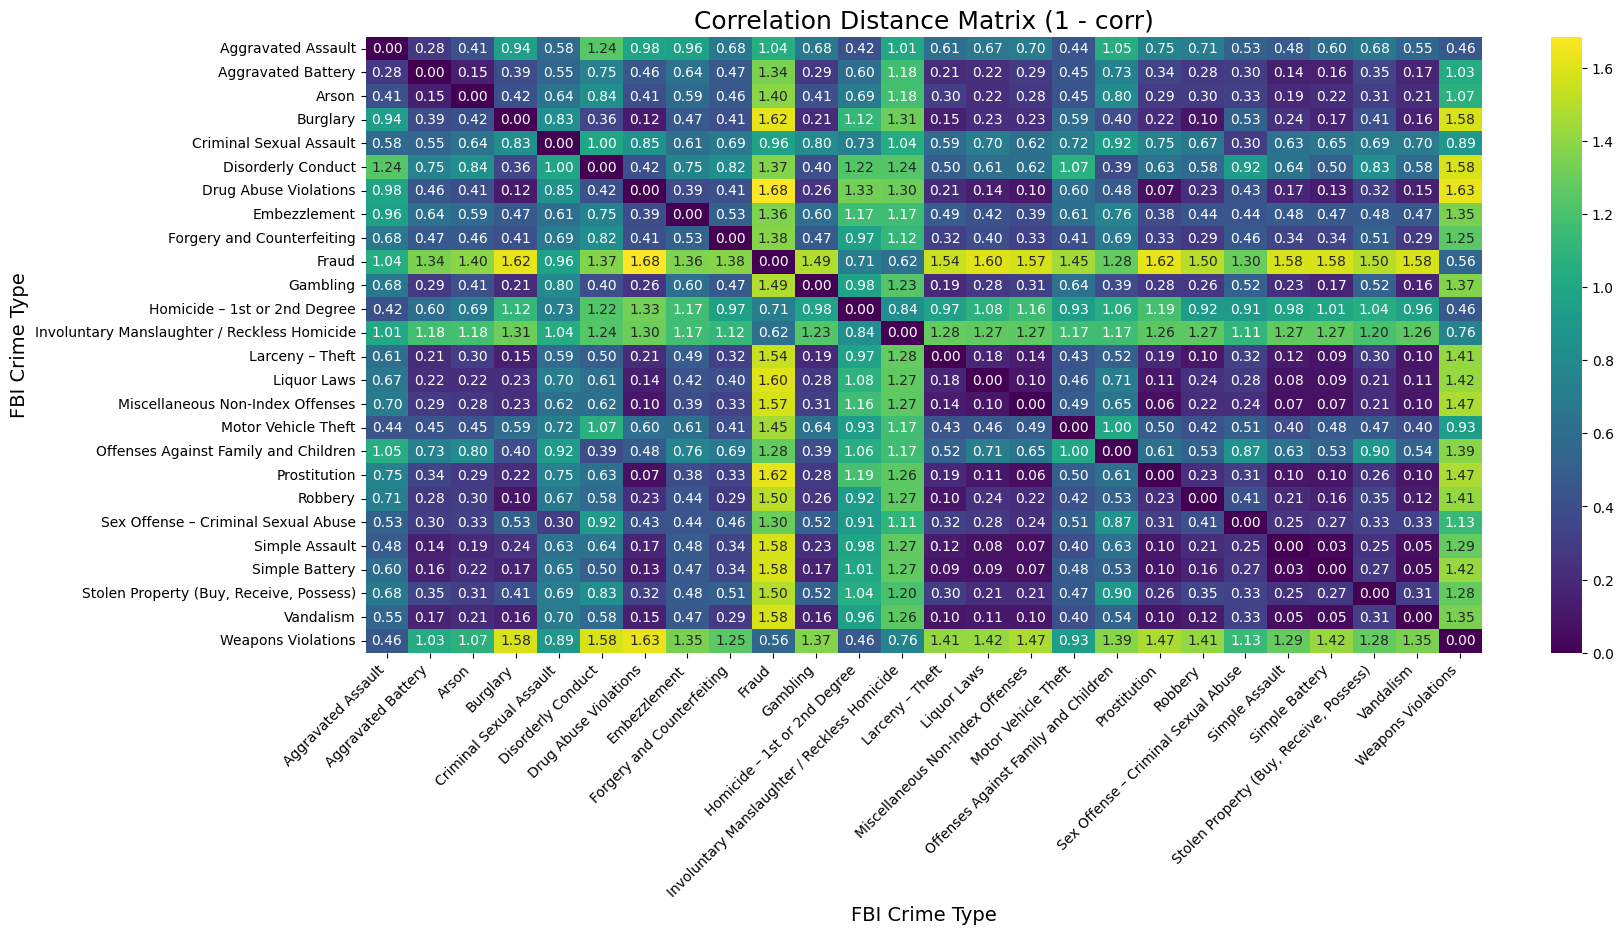

In [10]:
plt.figure(figsize=(18, 8))
sns.heatmap(dist_df, cmap="viridis", xticklabels=True, yticklabels=True, annot=True, fmt='.2f')
plt.title("Correlation Distance Matrix (1 - corr)", fontsize=18)
plt.xlabel("FBI Crime Type", fontsize=14)
plt.ylabel("FBI Crime Type", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

#### Linkage Method
* 'single'     - Nearest point (min distance between clusters) → long thin clusters
* 'complete'   - Farthest point (max distance) → compact spherical clusters  
* 'average'    - Average distance (UPGMA) → balanced, good default
* 'weighted'   - Weighted average → similar to average but size-aware
* 'centroid'   - Centroid distance (UPGMA) → sensitive to outliers
* 'median'     - WPGMC → robust to outliers
* 'ward'       - Minimize variance increase → compact clusters (uses Euclidean only)

#### Rule of thumb:
* With correlation distance, average or complete is usually safest. Single linkage is okay if you want to explore chains, but interpret with caution.

In [11]:
# List of hierarchical clustering linkage strategies
methods = ["complete", "average"]

# Iterate Linkage Method: Build linkage matrices for each method
Zs = {m: hierarchy.linkage(dist_condensed, method=m) for m in methods}

# Dictionary to store cophenetic correlation coefficients
ccc = {}
# Loop over linkage methods to evaluate them
for m in methods:
    # Compute the cophenetic correlation coefficient
    c, _ = hierarchy.cophenet(Zs[m], dist_condensed)
    # Store the score
    ccc[m] = c

# display highest
best_method = max(ccc, key=ccc.get)
print(ccc)
print("\n::::::::", best_method)

{'complete': np.float64(0.8634143862060111), 'average': np.float64(0.8756866850872262)}

:::::::: average


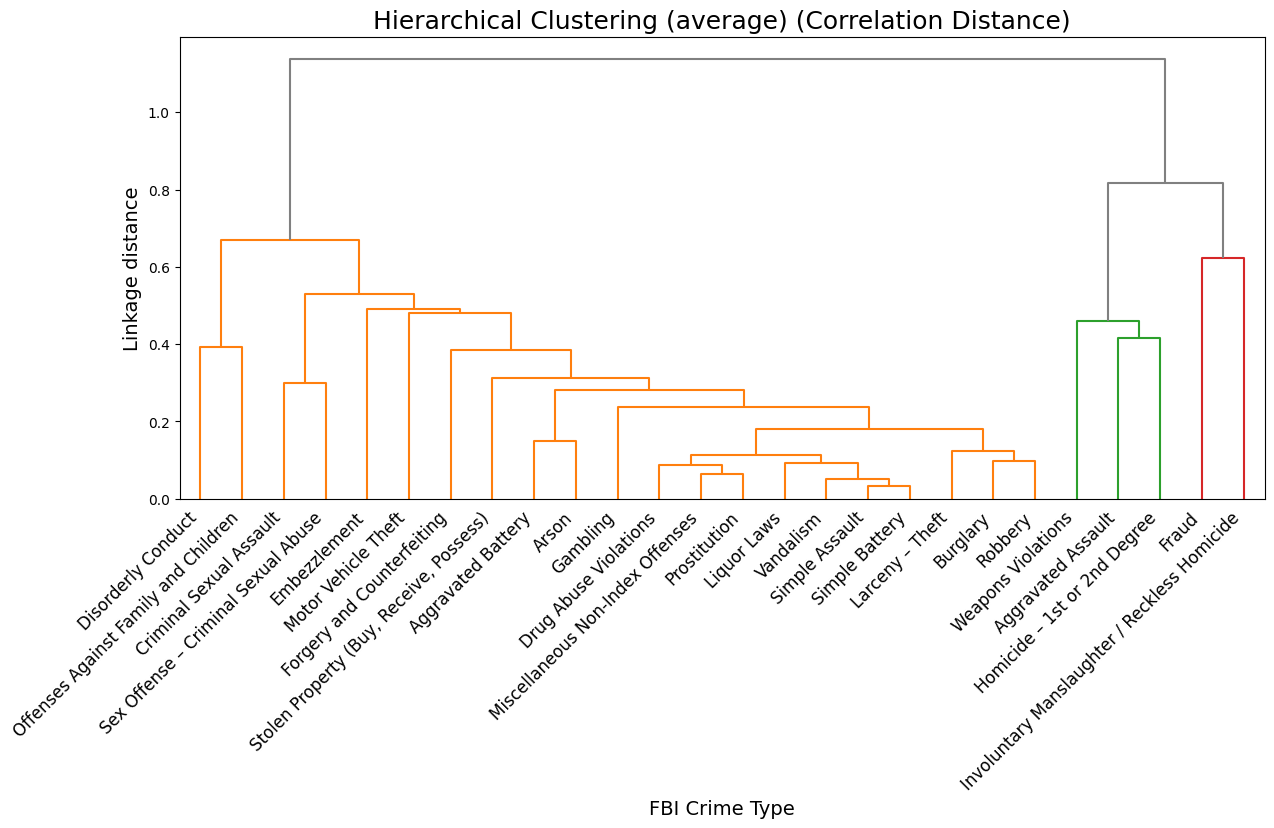

In [12]:
# Linkage Matrix
Z = hierarchy.linkage(dist_condensed,  method=best_method)
# plot
plt.figure(figsize=(14, 6))
hierarchy.dendrogram(Z, 
                     labels=z_row_df.index, 
                     leaf_rotation=90,
                     leaf_font_size = 12,
                     # color_threshold=0.4,     # Cut line 
                     above_threshold_color='gray'
                    )
# plt.axhline(y=0.4, c='k', ls='--', alpha=0.5)  # Show cut line
plt.title(f"Hierarchical Clustering ({best_method}) (Correlation Distance)", fontsize=18)
plt.ylabel("Linkage distance", fontsize=14)
plt.xlabel("FBI Crime Type", fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.show()

In [13]:
# R is (n-1) x 4 matrix:
# Col 0: mean height of links below
# Col 1: std of heights below  
# Col 2: count of links below
# Col 3: **inconsistency coefficient**
# Calculate inconsistency coefficients (depth=2 is standard)
R = hierarchy.inconsistent(Z, d=2)
# Extract coefficients & Heights
inconsistencies = R[:, 3] 
heights = Z[:,2]

In [14]:
# Z method: identify the largest jump in cluster heights 
gaps = np.diff(heights)
z_cut = np.argmax(gaps)  # Merge step with biggest jump
k_z = len(dist_matrix) - z_cut  

# R method: spikes ≥1.0
r_spikes = np.where(inconsistencies >= 1.0)[0]
k_r = len(r_spikes) + 1

print(f"Z gap method: k={k_z}")
print(f"R spike method: k={k_r}")

Z gap method: k=3
R spike method: k=6


In [15]:
# Checking the cluster sizes for both
labels_z = hierarchy.fcluster(Z, t=k_z, criterion='maxclust')
labels_r = hierarchy.fcluster(Z, t=k_r, criterion='maxclust')

print(np.unique(labels_z, return_counts=True))
print(np.unique(labels_r, return_counts=True))

(array([1, 2, 3], dtype=int32), array([21,  3,  2]))
(array([1, 2, 3, 4, 5, 6], dtype=int32), array([ 2,  2, 17,  3,  1,  1]))


#### Analysis of Cluster Distribution
* Z Method ($k=3$): One giant cluster of 21 points and two tiny clusters (3 and 2). This suggests your data has a very dense core with a few distinct outliers or small satellite groups.
* R Method ($k=6$): This method is trying to break into that giant cluster. It took the group of 21 and split it—likely into the new group of 17—while carving out even smaller micro-clusters of 1 or 2 points
#### The Verdict
* The R Method ($k=6$) is currently hyper-focusing on outliers. Having clusters with only 1 or 2 members in a dataset of this size usually indicates "noise" rather than meaningful groupings, unless you are specifically looking for anomalies (like fraud detection or rare disease cases).
* The Z Method ($k=3$) is giving you a more stable "big picture," but even then, it seems heavily dominated by one large mass.

#### Silhouette Score

In [16]:
# Silhouette Score
score_z = silhouette_score(z_row_df, labels_z)
score_r = silhouette_score(z_row_df, labels_r)

print(f"Silhouette Score for k=3 (Z-method): {score_z:.4f}")
print(f"Silhouette Score for k=6 (R-method): {score_r:.4f}")

Silhouette Score for k=3 (Z-method): 0.3401
Silhouette Score for k=6 (R-method): 0.2092


In [17]:
# FBI codes descriptions
crime_names = z_row_df.index.to_list() 

# Cluster & Crime type
crime_groups = (
    pd.DataFrame({
        'crime': crime_names,
        'cluster': labels_z
    })
    .sort_values('cluster')
)
# How many points are in each cluster
print("How many points are in each cluster:\n", np.unique(labels_z, return_counts=True), "\n")

# Display the members
unique_clusters = np.sort(crime_groups['cluster'].unique())
for cluster_num in unique_clusters:
    members = crime_groups.loc[crime_groups['cluster'] == cluster_num, 'crime'].tolist()
    print(f"--- Cluster {cluster_num} ---")
    print(members, "\n")

How many points are in each cluster:
 (array([1, 2, 3], dtype=int32), array([21,  3,  2])) 

--- Cluster 1 ---
['Gambling', 'Robbery', 'Prostitution', 'Offenses Against Family and Children', 'Motor Vehicle Theft', 'Miscellaneous Non-Index Offenses', 'Liquor Laws', 'Larceny – Theft', 'Vandalism', 'Simple Battery', 'Simple Assault', 'Stolen Property (Buy, Receive, Possess)', 'Forgery and Counterfeiting', 'Embezzlement', 'Drug Abuse Violations', 'Disorderly Conduct', 'Criminal Sexual Assault', 'Burglary', 'Arson', 'Aggravated Battery', 'Sex Offense – Criminal Sexual Abuse'] 

--- Cluster 2 ---
['Aggravated Assault', 'Weapons Violations', 'Homicide – 1st or 2nd Degree'] 

--- Cluster 3 ---
['Fraud', 'Involuntary Manslaughter / Reckless Homicide'] 



In [18]:
print("z_row_df.shape:", z_row_df.shape)   # -> (26, 300)
print("len(labels_z):", len(labels_z))

z_row_df.shape: (26, 300)
len(labels_z): 26


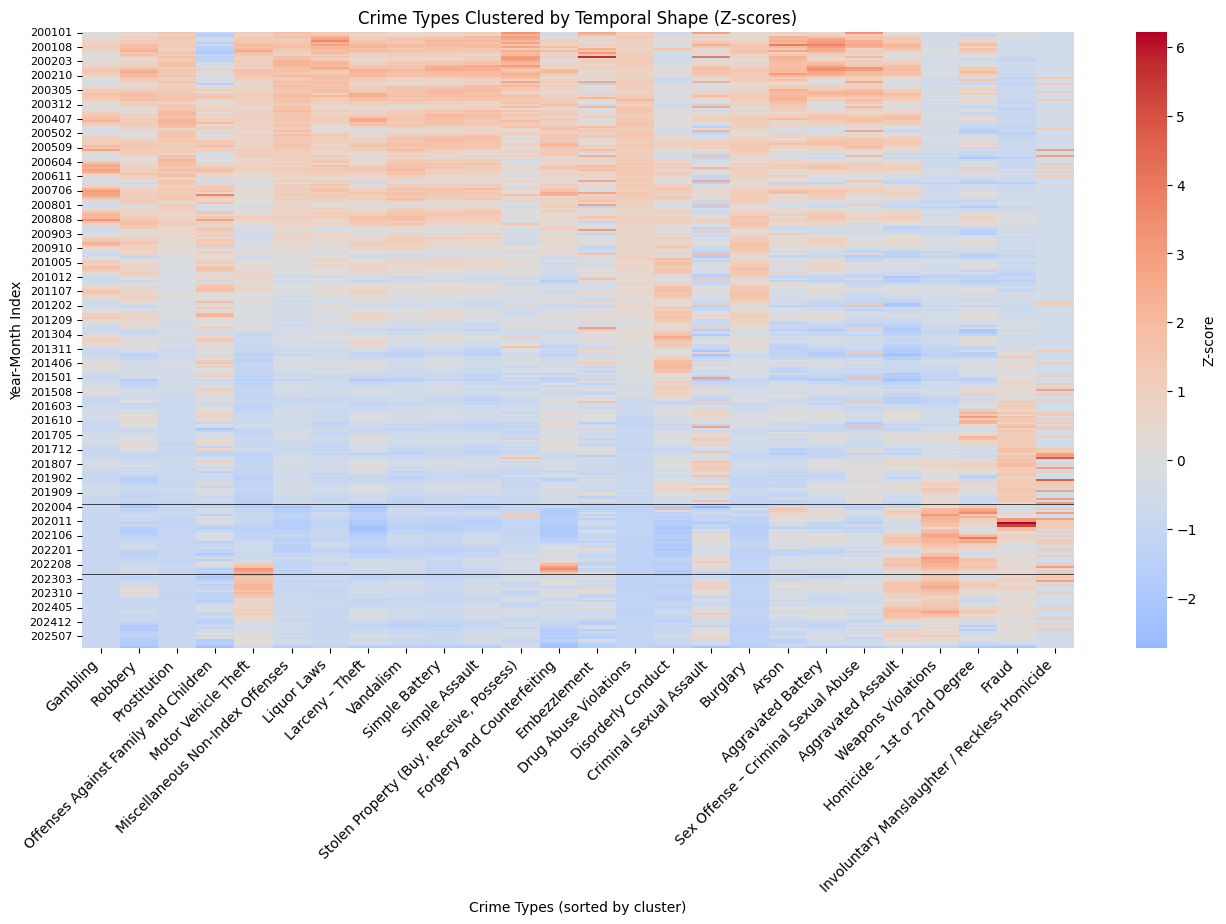

In [19]:
# Copy
z_row_df_with_labels = z_row_df.copy()
# Attach the labels back to the DataFrame
z_row_df_with_labels['cluster'] = labels_z

# Sort rows by cluster
z_plot_sorted = z_row_df_with_labels.sort_values('cluster')
#
plt.figure(figsize=(16, 8))
ax = sns.heatmap(
    z_plot_sorted.drop(columns='cluster').T,
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Z-score'}
)

plt.title("Crime Types Clustered by Temporal Shape (Z-scores)")
plt.ylabel("Year-Month Index")
plt.yticks(fontsize=8)
plt.xlabel("Crime Types (sorted by cluster)")
plt.xticks(rotation=45, ha='right')

# --- ERA BREAKPOINTS --------------------------------------------------
ym_index = z_plot_sorted.drop(columns='cluster').T.index

# Find the row index where each era begins
pre_end     = ym_index.get_loc(202002)   # last month of pre-COVID
covid_start = ym_index.get_loc(202003)   # first month of COVID
covid_end   = ym_index.get_loc(202212)   # last month of COVID
post_start  = ym_index.get_loc(202301)   # first month of post-COVID

# Draw horizontal lines (y coordinates are between rows)
ax.axhline(pre_end + 1,     color='black', linewidth=.5)
ax.axhline(covid_end + 1,   color='black', linewidth=.5)

# Display Plot
plt.show()

## [PCA (Principal Component Analysis)](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html)
* visualize the raw movement in your Z-scores
## [MDS (Multidimensional Scaling)](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.MDS.html)
* definitive map of how the relationships (correlations) changed over the 300 months
## [Procrustes Analysis](https://docs.scipy.org/doc/scipy/reference/generated/scipy.spatial.procrustes.html)
* A statistical method for shape analysis used to compare two sets of data points (shapes)

In [20]:
z_row_df.head()

year_month,200101,200102,200103,200104,200105,200106,200107,200108,200109,200110,200111,200112,200201,200202,200203,200204,200205,200206,200207,200208,200209,200210,200211,200212,200301,200302,200303,200304,200305,200306,200307,200308,200309,200310,200311,200312,200401,200402,200403,200404,200405,200406,200407,200408,200409,200410,200411,200412,200501,200502,200503,200504,200505,200506,200507,200508,200509,200510,200511,200512,200601,200602,200603,200604,200605,200606,200607,200608,200609,200610,200611,200612,200701,200702,200703,200704,200705,200706,200707,200708,200709,200710,200711,200712,200801,200802,200803,200804,200805,200806,200807,200808,200809,200810,200811,200812,200901,200902,200903,200904,200905,200906,200907,200908,200909,200910,200911,200912,201001,201002,201003,201004,201005,201006,201007,201008,201009,201010,201011,201012,201101,201102,201103,201104,201105,201106,201107,201108,201109,201110,201111,201112,201201,201202,201203,201204,201205,201206,201207,201208,201209,201210,201211,201212,201301,201302,201303,201304,201305,201306,201307,201308,201309,201310,201311,201312,201401,201402,201403,201404,201405,201406,201407,201408,201409,201410,201411,201412,201501,201502,201503,201504,201505,201506,201507,201508,201509,201510,201511,201512,201601,201602,201603,201604,201605,201606,201607,201608,201609,201610,201611,201612,201701,201702,201703,201704,201705,201706,201707,201708,201709,201710,201711,201712,201801,201802,201803,201804,201805,201806,201807,201808,201809,201810,201811,201812,201901,201902,201903,201904,201905,201906,201907,201908,201909,201910,201911,201912,202001,202002,202003,202004,202005,202006,202007,202008,202009,202010,202011,202012,202101,202102,202103,202104,202105,202106,202107,202108,202109,202110,202111,202112,202201,202202,202203,202204,202205,202206,202207,202208,202209,202210,202211,202212,202301,202302,202303,202304,202305,202306,202307,202308,202309,202310,202311,202312,202401,202402,202403,202404,202405,202406,202407,202408,202409,202410,202411,202412,202501,202502,202503,202504,202505,202506,202507,202508,202509,202510,202511,202512
fbi_code_desc,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Aggravated Assault,0.190405,0.108216,1.086270,1.415027,1.357494,1.571187,2.130075,1.990353,1.719128,1.078051,0.584914,-0.097257,0.436973,-0.450672,0.724636,1.135583,1.727347,1.858850,1.932820,1.530092,1.834193,1.143802,-0.047944,0.067121,-0.105476,-0.442453,0.420536,0.363003,1.176678,1.078051,1.990353,1.513654,1.308181,1.102707,0.486287,0.132873,-0.327388,-0.097257,0.790388,0.527382,1.579406,1.793098,1.719128,1.127364,1.176678,0.913672,0.001370,-0.516423,-0.952027,-0.467110,0.223281,0.913672,1.045175,1.431465,1.299962,0.864358,0.453411,0.453411,-0.302731,-1.017778,0.132873,-0.968465,-0.105476,0.469849,0.847920,0.576695,1.283524,0.930110,0.338346,0.124654,-0.491766,-0.483547,-1.009559,-1.297222,0.239719,0.124654,0.675323,0.650666,0.880796,0.683542,0.650666,0.280814,-0.606832,-0.771210,-0.656145,-1.206814,-0.253417,0.650666,0.428755,0.749293,1.127364,0.962985,0.502725,-0.031506,-1.025997,-1.445163,-0.976684,-1.034216,0.083559,0.256157,0.280814,0.313689,0.478068,0.617790,0.017808,-0.261636,-0.721897,-1.305441,-1.297222,-1.404068,-0.615050,-0.171228,-0.039725,-0.261636,-0.163009,-0.730116,-0.245198,-0.541080,-0.804086,-1.913643,-1.469820,-1.708169,-1.075311,-0.565737,-0.360263,-0.097257,0.165749,-0.499985,-0.352044,-0.779429,-1.256128,-1.182157,-2.061583,-1.856110,-0.483547,-0.993122,-0.623269,-0.327388,-0.310950,-0.442453,-0.869838,-0.935589,-1.223252,-1.387631,-1.716388,-1.897205,-1.552009,-1.289003,-0.828743,-0.976684,-1.091749,-0.894494,-1.305441,-1.338317,-1.773921,-1.823234,-1.971175,-2.447873,-1.716388,-1.486258,-0.746553,-0.713678,-0.795867,-0.8

## PCA & PCoA & MDS


Procrustes Disparity:
PCA vs PCoA: 0.0253
PCA vs MDS:  0.0689
PCoA vs MDS: 0.0389

Variance explained: PC1 = 40.66% & PC2 = 15.82% & PC3 = 8.90%
Variance of PCoA dims: Dim1 = 20.93% & Dim2 = 6.34% & Dim3 = 2.84%
Variance of MDS dims: Dim1 = 11.79% & Dim2 = 5.48% & Dim3 = 11.50%

Kruskal's Stress-1: 0.0857 with 3 conponents.



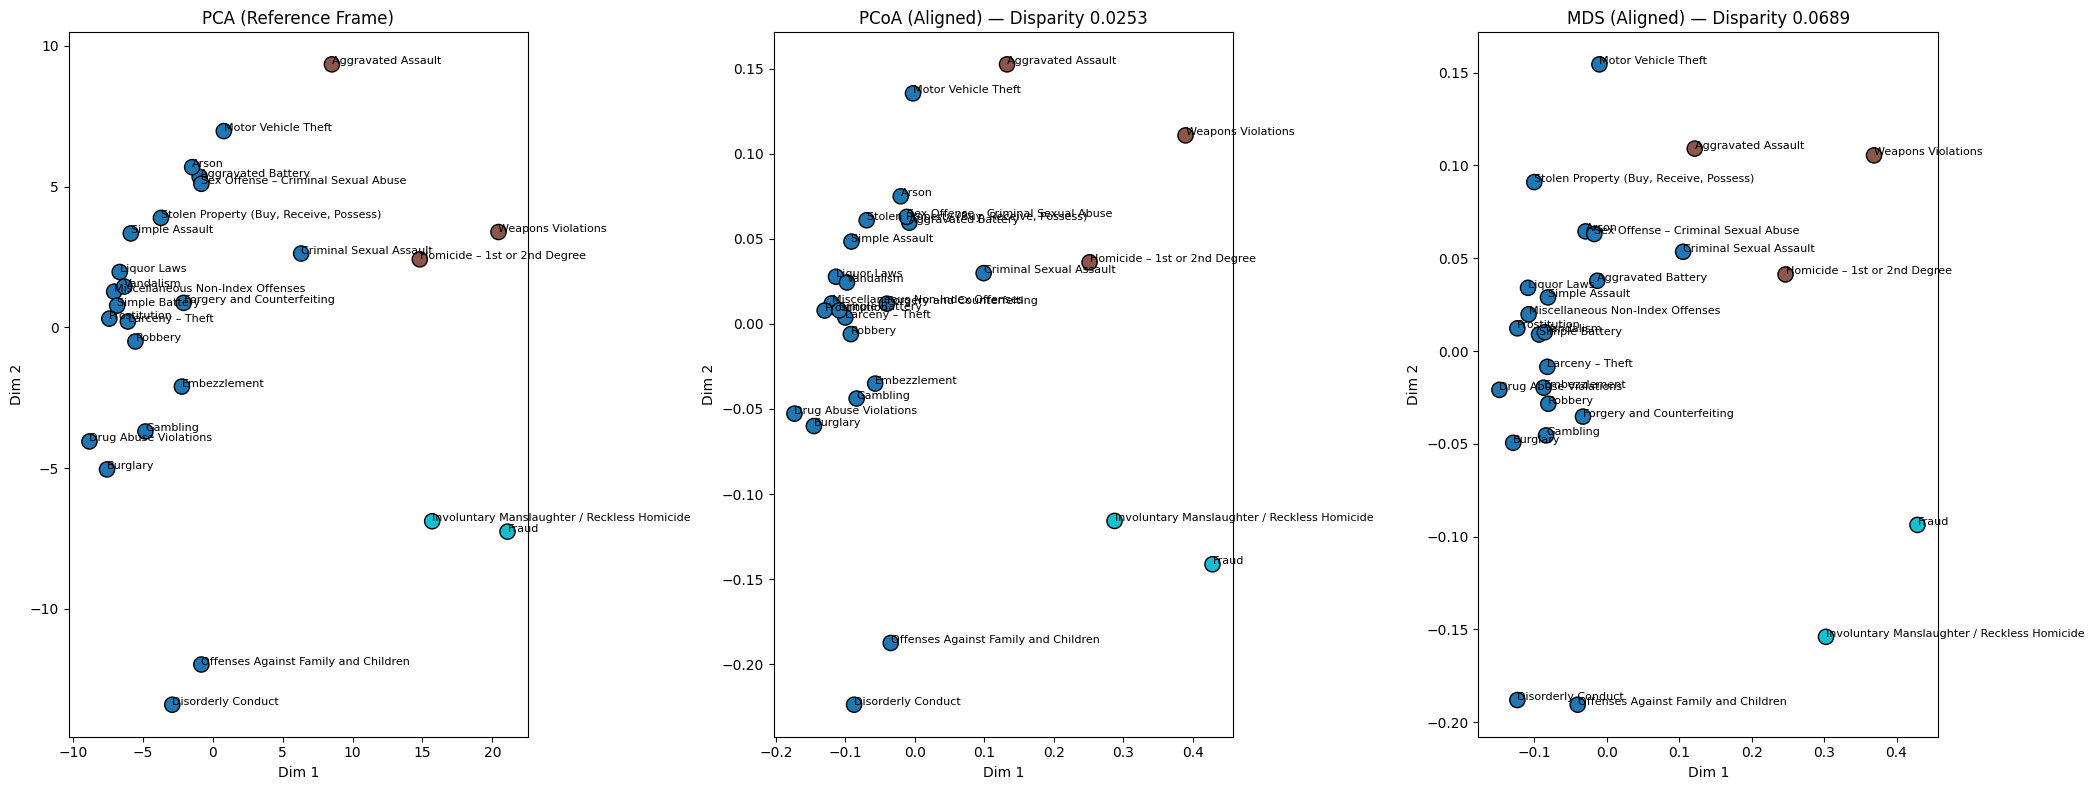

In [43]:
# Initialize variables
n_components = 3

# PCA on z-score matrix (26 × 300)
pca = PCA(n_components=n_components)
coords_pca = pca.fit_transform(z_row_df.values)   # (26, 2)

# PCoA on distance matrix (26 × 26)
D2 = dist_matrix ** 2                 # Square the distances
n = D2.shape[0]
J = np.eye(n) - np.ones((n, n)) / n   # Build the centering matrix
# B is a Gram matrix: a matrix of all pairwise inner products of a set of vectors
B = -0.5 * J @ D2 @ J                 # Double‑center the squared distances

# Eigen‑decompose the Gram matrix
eigvals, eigvecs = np.linalg.eigh(B)
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# PCoA embedding
coords_pcoa = eigvecs[:, :n_components] * np.sqrt(eigvals[:n_components]) 

# MDS on distance matrix (26 × 26)
mds = MDS(
    n_components=n_components,
    metric='precomputed',   # use precomputed distances
    n_init=n_init,
    init = 'random' if n_components > 2 else 'classical_mds',
    max_iter=max_iter,
    normalized_stress=True,
    random_state=SEED
)
# mds embedding
coords_mds = mds.fit_transform(dist_matrix)          

# Procrustes alignment: use PCA as the reference frame
_, pcoa_aligned, disp_pcoa = procrustes(coords_pca, coords_pcoa)
_, mds_aligned, disp_mds   = procrustes(coords_pca, coords_mds)
_, pcoa_aligned_mds, disp_pcoa_mds = procrustes(coords_pcoa, coords_mds)
print("\nProcrustes Disparity:")
print(f"PCA vs PCoA: {disp_pcoa:.4f}")
print(f"PCA vs MDS:  {disp_mds:.4f}")
print(f"PCoA vs MDS: {disp_pcoa_mds:.4f}\n")

# Plot all three side-by-side
fig, axes = plt.subplots(1, 3, figsize=(21, 8))

# plot tile display
titles = [
    "PCA (Reference Frame)",
    f"PCoA (Aligned) — Disparity {disp_pcoa:.4f}",
    f"MDS (Aligned) — Disparity {disp_mds:.4f}"
]

# Embeddings for each analysis
embeddings = [coords_pca, pcoa_aligned, mds_aligned]

# Iterate and plot
for ax, emb, title in zip(axes, embeddings, titles):
    ax.scatter(
        emb[:,0], emb[:,1],
        c=labels_z,  # from CLustering
        cmap='tab10',
        s=120,
        edgecolor='black'
    )
    for i, crime in enumerate(z_row_df.index):
        ax.text(emb[i,0], emb[i,1], crime, fontsize=8)
    ax.set_title(title)
    ax.set_xlabel("Dim 1")
    ax.set_ylabel("Dim 2")

# Explained variance for each PC
var_explained = pca.explained_variance_ratio_
print("Variance explained: " + " & ".join(
    [f"PC{i+1} = {v:.2%}" for i, v in enumerate(var_explained)]
))

# Display the variance of each PCoA dimension
var_pcoa = np.var(coords_pcoa, axis=0)
print("Variance of PCoA dims: " + " & ".join(
    [f"Dim{i+1} = {v*100:.2f}%" for i, v in enumerate(var_pcoa)]
))

# Display the variance of each MDS dimension
dim_var = np.var(coords_mds, axis=0)
print("Variance of MDS dims: " + " & ".join(
    [f"Dim{i+1} = {v*100:.2f}%" for i, v in enumerate(dim_var)]
))
print(f"\nKruskal's Stress-1: {mds.stress_:.4f} with {n_components} conponents.\n")

plt.tight_layout()
# Save the figure with high resolution and tight cropping
plt.savefig("../Image/pca_pcoa_mds.png", dpi=1200, bbox_inches='tight')
plt.show()

## Factor Analysis

In [51]:
from sklearn.decomposition import FactorAnalysis

# Transpose your data: We want (300 months, 26 crimes)
# Factor Analysis looks for correlations between the columns (crimes)
X = z_row_df.T 

# Initialize and Fit
# We choose n_components to match your Dim1 and Dim2 or/and Dim...
fa = FactorAnalysis(n_components=n_components, random_state=SEED)
fa.fit(X)

# Extract the Loadings
# Loadings are in fa.components_. We transpose them to align with crime names.
loadings_df = pd.DataFrame(
    fa. components_.T, 
    index=z_row_df.index, 
    columns=['Factor1_Loading', 'Factor2_Loading', 'Factor3_Loading']
)

# View the "Top" crimes for each Factor
print("--- Top Crimes for Dim1 (X-Axis) ---")
print(loadings_df.loc[abs(loadings_df.Factor1_Loading) > .6, 'Factor1_Loading'].sort_values(ascending=False))

print("\n--- Top Crimes for Dim2 (Y-Axis) ---")
print(loadings_df.loc[abs(loadings_df.Factor2_Loading) > .6, 'Factor2_Loading'].sort_values(ascending=False))

print("\n--- Top Crimes for Dim3 (Z-Axis) ---")
print(loadings_df.loc[abs(loadings_df.Factor3_Loading) > .2, 'Factor3_Loading'].sort_values(ascending=False))

--- Top Crimes for Dim1 (X-Axis) ---
fbi_code_desc
Simple Battery                             0.983451
Simple Assault                             0.970035
Vandalism                                  0.968563
Miscellaneous Non-Index Offenses           0.951853
Prostitution                               0.938568
Liquor Laws                                0.933559
Larceny – Theft                            0.918661
Drug Abuse Violations                      0.910341
Robbery                                    0.862463
Burglary                                   0.858395
Gambling                                   0.817632
Aggravated Battery                         0.813305
Arson                                      0.787214
Stolen Property (Buy, Receive, Possess)    0.762922
Sex Offense – Criminal Sexual Abuse        0.728588
Forgery and Counterfeiting                 0.686314
Fraud                                     -0.620926
Name: Factor1_Loading, dtype: float64

--- Top Crimes for Dim2 (Y

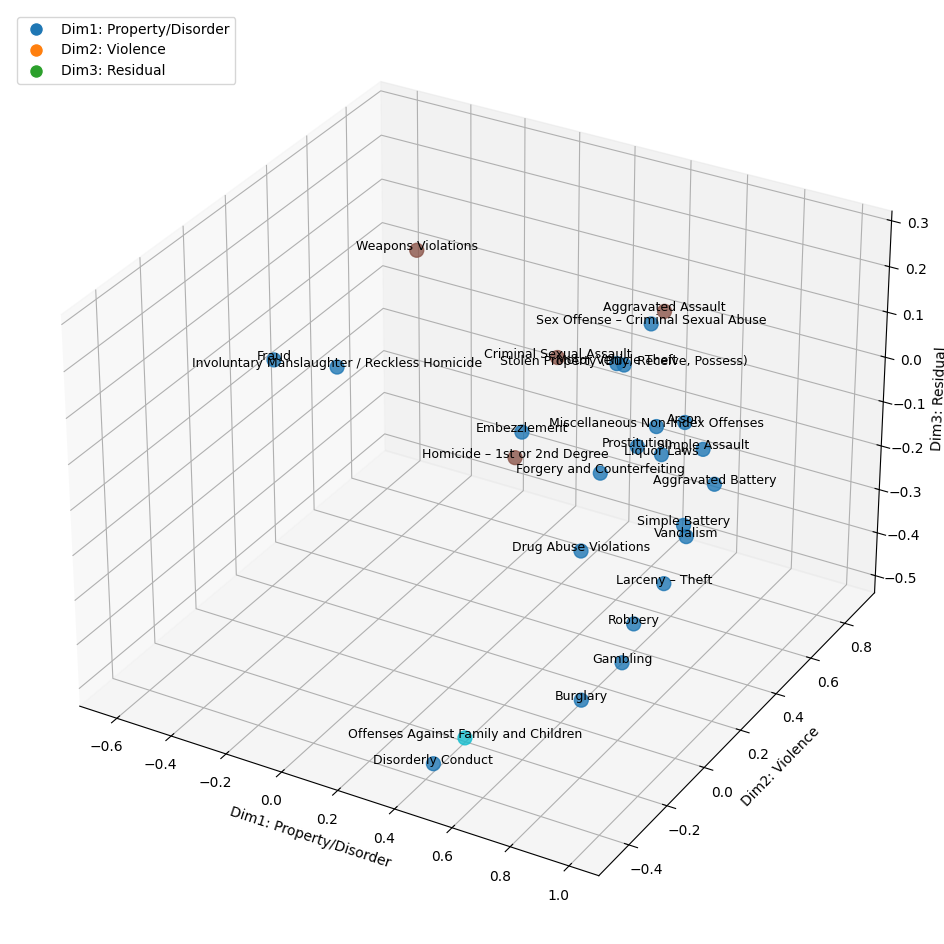

In [61]:
fig = plt.figure(figsize=(16,12))
ax = fig.add_subplot(111, projection='3d')

# Color points by dominant dimension
colors = np.argmax([
    np.abs(loadings_df.Factor1_Loading), 
    np.abs(loadings_df.Factor2_Loading), 
    np.abs(loadings_df.Factor3_Loading)
], axis=0)

scatter = ax.scatter(loadings_df.Factor1_Loading, loadings_df.Factor2_Loading, loadings_df.Factor3_Loading, 
           c=colors, cmap='tab10', s=100, alpha=0.8)

# Custom legend for dominant dimensions
legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:blue', 
                markersize=10, label='Dim1: Property/Disorder'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:orange', 
                markersize=10, label='Dim2: Violence'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='tab:green', 
                markersize=10, label='Dim3: Residual')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(0,1))

# Label each crime
for i, crime in enumerate(loadings_df.index):
    ax.text(loadings_df.iloc[i,0], loadings_df.iloc[i,1], loadings_df.iloc[i,2], crime, 
            fontsize=9, ha='center')

ax.set_xlabel('Dim1: Property/Disorder')
ax.set_ylabel('Dim2: Violence') 
ax.set_zlabel('Dim3: Residual')
plt.show()



In [ ]:
# 'df' has 26 rows (crimes) and 300 columns (months)
pre_covid = df.iloc[:, :264]
covid = df.iloc[:, 264:288]
post_covid = df.iloc[:, 288:]

eras = {"Pre": pre_covid, "COVID": covid, "Post": post_covid}

def run_dual_analysis(data_dict):
    results = {}
    
    for name, era_data in data_dict.items():
        # A. PCA Calculation (Variance-based)
        pca = PCA(n_components=2)
        pca_coords = pca.fit_transform(era_data)
        
        # B. MDS Calculation (Relationship-based)
        # We calculate Correlation Distance (1 - Pearson R)
        corr_matrix = era_data.T.corr()
        dist_matrix = 1 - corr_matrix
        
        mds = MDS(n_components=2, dissimilarity='precomputed', random_state=42, normalized_stress='auto')
        mds_coords = mds.fit_transform(dist_matrix)
        
        results[name] = {'pca': pca_coords, 'mds': mds_coords}
    
    return results

analysis = run_dual_analysis(eras)

# 2. VISUALIZATION: Temporal Trajectory Map
def plot_trajectory(method_key, title):
    plt.figure(figsize=(12, 8))
    crimes = df.index
    
    for i in range(len(crimes)):
        # Extract points for Pre, COVID, Post
        p1 = analysis['Pre'][method_key][i]
        p2 = analysis['COVID'][method_key][i]
        p3 = analysis['Post'][method_key][i]
        
        # Plot trajectory line
        plt.plot([p1[0], p2[0], p3[0]], [p1[1], p2[1], p3[1]], color='black', alpha=0.1)
        
        # Plot points
        plt.scatter(p1[0], p1[1], color='blue', label='Pre' if i==0 else "", alpha=0.6)
        plt.scatter(p2[0], p2[1], color='red', marker='X', label='COVID' if i==0 else "", s=60)
        plt.scatter(p3[0], p3[1], color='green', label='Post' if i==0 else "", alpha=0.6)
        
        # Label select crimes (e.g., first 5)
        if i < 5:
            plt.text(p3[0], p3[1], crimes[i], fontsize=9)

    plt.title(title)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_trajectory('pca', 'PCA Trajectory: Magnitude of Variance Shift')
plot_trajectory('mds', 'MDS Trajectory: Correlation Distance Shift')

In [ ]:






# 4) Compute centroids using only the crime columns
centroids = df.groupby('cluster')[crime_cols].mean().sort_index()
print("centroids.shape:", centroids.shape)   # should be (n_clusters, 26)
